In [6]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [42, 7, 13]
NUM_TRIALS = 1000

In [7]:
def centrality_route(G, src, dst, centrality):
    if src == dst:
        return [src], 0
    path = [src]
    current = src
    visited = set([src])
    for _ in range(50):
        neighbors = [n for n in G.neighbors(current) if n not in visited]
        if not neighbors:
            return None, float('inf')
        next_hop = max(neighbors, key=lambda n: centrality[n])
        path.append(next_hop)
        visited.add(next_hop)
        if next_hop == dst:
            return path, len(path) - 1
        current = next_hop
    return None, float('inf')

In [8]:
all_results = []

for seed in SEEDS:
    np.random.seed(seed)
    G = nx.erdos_renyi_graph(50, 0.15, seed=seed)
    for u, v in G.edges():
        G[u][v]['latency'] = round(np.random.uniform(1, 10), 2)

    betweenness = nx.betweenness_centrality(G)
    degree      = nx.degree_centrality(G)
    closeness   = nx.closeness_centrality(G)
    nodes       = list(G.nodes())

    for method, centrality in [('BCR', betweenness),
                                ('DCR', degree),
                                ('CCR', closeness)]:
        for i in range(NUM_TRIALS):
            src = np.random.choice(nodes)
            dst = np.random.choice([n for n in nodes if n != src])
            path, hops = centrality_route(G, src, dst, centrality)
            delivered = path is not None
            delay = sum(G[path[j]][path[j+1]]['latency']
                        for j in range(len(path)-1)) if delivered else 0
            all_results.append({'seed':seed, 'method':method,
                                'delivered':delivered,
                                'hops':hops, 'delay':delay})

df = pd.DataFrame(all_results)
df.to_csv("../results/baseline_kpis.csv", index=False)
print("Saved — total rows:", len(df))

Saved — total rows: 9000


In [13]:
# Calculate summary correctly
summary_rows = []
for method in ['BCR', 'CCR', 'DCR']:
    method_df = df[df['method'] == method]
    delivered = method_df[method_df['delivered'] == True]
    
    pdr       = round(method_df['delivered'].mean() * 100, 2)
    avg_delay = round(delivered['delay'].mean(), 2)
    avg_hops  = round(delivered['hops'].mean(), 2)
    
    summary_rows.append({'Method': method, 'PDR (%)': pdr,
                         'Avg Delay (ms)': avg_delay, 'Avg Hops': avg_hops})

summary = pd.DataFrame(summary_rows)

per_seed = df.groupby(['seed', 'method']).agg(
    PDR = ('delivered', lambda x: round(x.mean() * 100, 2))
).reset_index()

print("=== Overall (3 seeds x 1000 trials each) ===")
print(summary.to_string(index=False))
print("\n=== Per Seed PDR ===")
print(per_seed.to_string(index=False))

=== Overall (3 seeds x 1000 trials each) ===
Method  PDR (%)  Avg Delay (ms)  Avg Hops
   BCR    66.70           97.41     17.39
   CCR    62.43           84.74     16.61
   DCR    67.07           90.90     17.46

=== Per Seed PDR ===
 seed method  PDR
    7    BCR 68.8
    7    CCR 62.0
    7    DCR 68.4
   13    BCR 58.4
   13    CCR 54.8
   13    DCR 60.3
   42    BCR 72.9
   42    CCR 70.5
   42    DCR 72.5


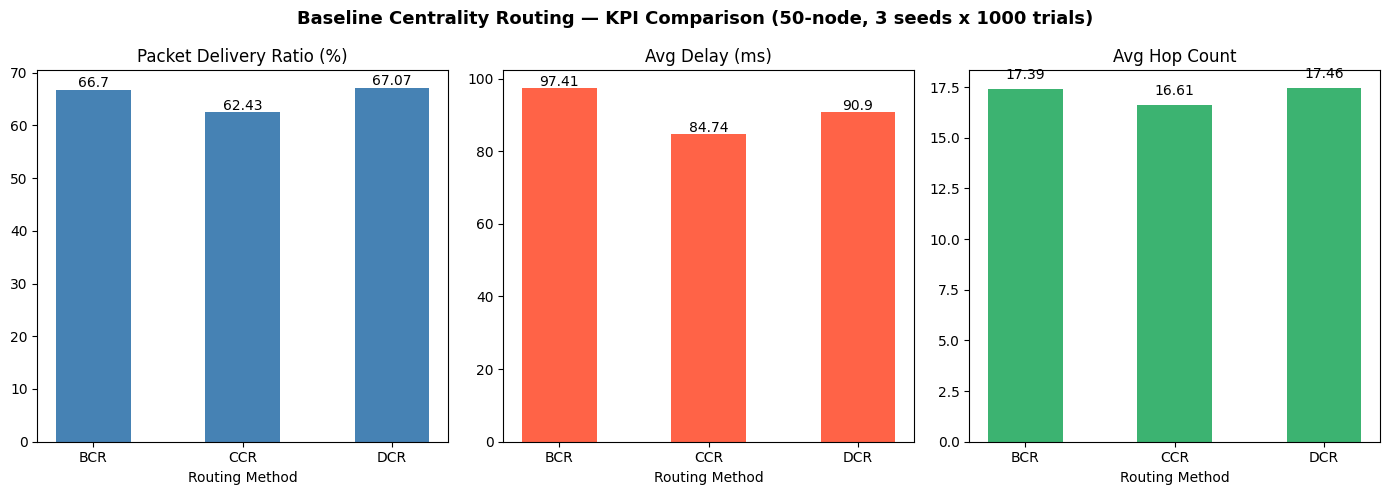

Saved!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['PDR (%)', 'Avg Delay (ms)', 'Avg Hops']
titles  = ['Packet Delivery Ratio (%)', 'Avg Delay (ms)', 'Avg Hop Count']
colors  = ['steelblue', 'tomato', 'mediumseagreen']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(summary['Method'], summary[metric], color=color, width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Routing Method')
    for i, v in enumerate(summary[metric]):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.suptitle('Baseline Centrality Routing — KPI Comparison (50-node, 3 seeds x 1000 trials)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/week2_baseline_comparison.png", dpi=150)
plt.show()
print("Saved!")